# Stage 3 — Text Preprocessing
## Spam Comment Detector — Thesis Project

**Goal of this notebook:**
Take the raw text from our dataset and transform it into clean, standardized text
that a Machine Learning model can work with effectively.

**Why does text need preprocessing?**

Raw text is messy. Consider these two spam comments:
- `"Join Casino99 NOW!!! Get FREE spins!!!"`
- `"join casino99 now get free spins"`

To a computer, these look completely different — but they carry the same meaning.
Text preprocessing removes the noise so the model focuses on what matters: **the words**.

**What we will do in this notebook:**
1. Lowercase all text
2. Remove punctuation and numbers
3. Tokenize (split text into individual words)
4. Remove stopwords (common words with no signal: "the", "a", "is")
5. Apply stemming (reduce words to their root form)
6. Build a reusable `clean_text()` function
7. Apply it to the full dataset and save the result

**Input:** `data/raw/comments.csv` (80 rows, raw text)
**Output:** `data/processed/comments_clean.csv` (80 rows, cleaned text)

## Section 1 — Imports & NLTK Setup

We need a new library here: **NLTK** (Natural Language Toolkit).
NLTK is a Python library specifically built for working with human language text.

We use two things from NLTK:
- **stopwords** — a pre-built list of common English words to filter out ("the", "a", "is", "and"...)
- **PorterStemmer** — an algorithm that reduces words to their root form ("playing" → "play", "betting" → "bet")

The first time you use NLTK resources, you must **download** them (like installing a plugin).
We only need to do this once.

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download required NLTK data (only needed once)
# 'stopwords' = list of common words to filter out
# 'punkt'     = tokenizer models (older format)
# 'punkt_tab' = tokenizer models (newer format, required by nltk 3.9+)
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Load the NLTK English stopwords list
STOPWORDS = set(stopwords.words('english'))

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

print("Libraries loaded successfully.")
print(f"\nNLTK English stopwords count: {len(STOPWORDS)}")
print(f"\nSample stopwords: {sorted(list(STOPWORDS))[:20]}")


Libraries loaded successfully.

NLTK English stopwords count: 198

Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


## Section 2 — Load Raw Data

We always start from `data/raw/` — the original, untouched dataset.
We never modify this file. The cleaned output goes to `data/processed/`.

In [2]:
import os

DATA_RAW  = os.path.join('..', 'data', 'raw',       'comments.csv')
DATA_OUT  = os.path.join('..', 'data', 'processed', 'comments_clean.csv')

df = pd.read_csv(DATA_RAW)

print(f"Loaded: {DATA_RAW}")
print(f"Shape : {df.shape}")
print()
print(df.head(6).to_string(index=False))


Loaded: ..\data\raw\comments.csv
Shape : (80, 2)

                                            comment label
Great video! Really helped me understand the topic.   ham
      Can you make a tutorial on Python decorators?   ham
 This is exactly what I was looking for, thank you!   ham
     I've watched this 3 times already, so helpful!   ham
  Could you explain the part about recursion again?   ham
             Amazing content as always, keep it up!   ham


## Section 3 — Understanding Each Preprocessing Step

Before building the full pipeline, we will apply each step one at a time on a single
example comment so you can **see exactly what each step does**.

We will use this spam comment as our example throughout:
> `"Join Casino99 NOW!!! Get 100% FREE spins & WIN Big Money!!!"`

In [3]:
# Our example comment
example = "Join Casino99 NOW!!! Get 100% FREE spins & WIN Big Money!!!"
print("ORIGINAL:")
print(f"  {example!r}")
print()

# -----------------------------------------------------------------
# STEP 1: Lowercase
# -----------------------------------------------------------------
# "Casino" and "casino" are the same word — but a computer sees them
# as different strings. .lower() makes everything uniform.
step1 = example.lower()
print("STEP 1 - Lowercase:")
print(f"  {step1!r}")
print()

# -----------------------------------------------------------------
# STEP 2: Remove punctuation and numbers
# -----------------------------------------------------------------
# Punctuation (!!! ??? ...) and numbers (99, 100) add noise.
# re.sub() uses a Regular Expression to replace anything that is NOT
# a letter or a space with an empty string ''.
# [^a-z ] means: "anything NOT a-z or a space"
step2 = re.sub(r'[^a-z ]', '', step1)
print("STEP 2 - Remove punctuation & numbers:")
print(f"  {step2!r}")
print()

# -----------------------------------------------------------------
# STEP 3: Tokenize
# -----------------------------------------------------------------
# Tokenization = splitting the string into a LIST of individual words.
# .split() splits on whitespace by default.
# Each word is called a "token" — that's where the name comes from.
step3 = step2.split()
print("STEP 3 - Tokenize (split into list of words):")
print(f"  {step3}")
print(f"  Token count: {len(step3)}")
print()

# -----------------------------------------------------------------
# STEP 4: Remove stopwords
# -----------------------------------------------------------------
# Stopwords are common words that appear in ALL types of text and
# carry no useful signal: "the", "a", "is", "get", "and"...
# Removing them reduces noise and shrinks the vocabulary.
step4 = [w for w in step3 if w not in STOPWORDS]
removed = [w for w in step3 if w in STOPWORDS]
print("STEP 4 - Remove stopwords:")
print(f"  Removed : {removed}")
print(f"  Kept    : {step4}")
print()

# -----------------------------------------------------------------
# STEP 5: Stemming
# -----------------------------------------------------------------
# Stemming reduces a word to its base/root form so that variations
# of the same word are treated as one:
#   "betting" -> "bet"
#   "spinning" -> "spin"
#   "winning" -> "win"
#   "casinos" -> "casino"
# PorterStemmer is the most common algorithm for English stemming.
step5 = [stemmer.stem(w) for w in step4]
print("STEP 5 - Stemming (reduce words to root):")
for original, stemmed in zip(step4, step5):
    if original != stemmed:
        print(f"  {original:15} -> {stemmed}")
    else:
        print(f"  {original:15}    (unchanged)")
print()

print("FINAL RESULT:")
final = ' '.join(step5)
print(f"  {final!r}")


ORIGINAL:
  'Join Casino99 NOW!!! Get 100% FREE spins & WIN Big Money!!!'

STEP 1 - Lowercase:
  'join casino99 now!!! get 100% free spins & win big money!!!'

STEP 2 - Remove punctuation & numbers:
  'join casino now get  free spins  win big money'

STEP 3 - Tokenize (split into list of words):
  ['join', 'casino', 'now', 'get', 'free', 'spins', 'win', 'big', 'money']
  Token count: 9

STEP 4 - Remove stopwords:
  Removed : ['now']
  Kept    : ['join', 'casino', 'get', 'free', 'spins', 'win', 'big', 'money']

STEP 5 - Stemming (reduce words to root):
  join               (unchanged)
  casino             (unchanged)
  get                (unchanged)
  free               (unchanged)
  spins           -> spin
  win                (unchanged)
  big                (unchanged)
  money              (unchanged)

FINAL RESULT:
  'join casino get free spin win big money'


## Section 4 — Building the `clean_text()` Function

Now that we understand each step, we combine them into a single reusable function.
This is a core software engineering principle: **Don't Repeat Yourself (DRY)**.

Instead of copy-pasting 5 steps every time we want to clean a comment, we write it
once as a function and call it everywhere. Later, we'll move this function to
`src/preprocessing.py` so it can be imported by any notebook or script.

In [4]:
def clean_text(text: str) -> str:
    """
    Full text preprocessing pipeline for spam detection.

    Steps:
      1. Lowercase
      2. Remove punctuation and numbers (keep only letters and spaces)
      3. Tokenize (split into list of words)
      4. Remove NLTK English stopwords
      5. Apply Porter Stemming
      6. Re-join tokens into a single cleaned string

    Parameters
    ----------
    text : str
        Raw comment text.

    Returns
    -------
    str
        Cleaned, normalized comment text.
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and numbers
    text = re.sub(r'[^a-z ]', '', text)

    # Step 3: Tokenize
    tokens = text.split()

    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]

    # Step 5: Stem
    tokens = [stemmer.stem(t) for t in tokens]

    # Step 6: Rejoin into a string
    return ' '.join(tokens)


# Quick test
print("clean_text() defined successfully.\n")
print("Tests:")

test_cases = [
    "Great video, keep it up! Very helpful content.",
    "Join Casino99 NOW!!! Get 100% FREE spins & WIN Big Money!!!",
    "I LOVE your tutorials, they are so educational!",
    "Register at BettingKing and DEPOSIT now for bonus spins!!!",
]

for raw in test_cases:
    cleaned = clean_text(raw)
    print(f"  IN : {raw!r}")
    print(f"  OUT: {cleaned!r}")
    print()


clean_text() defined successfully.

Tests:
  IN : 'Great video, keep it up! Very helpful content.'
  OUT: 'great video keep help content'

  IN : 'Join Casino99 NOW!!! Get 100% FREE spins & WIN Big Money!!!'
  OUT: 'join casino get free spin win big money'

  IN : 'I LOVE your tutorials, they are so educational!'
  OUT: 'love tutori educ'

  IN : 'Register at BettingKing and DEPOSIT now for bonus spins!!!'
  OUT: 'regist bettingk deposit bonu spin'



## Section 5 — Apply `clean_text()` to the Full Dataset

Now we run `clean_text()` on every single row in our DataFrame.
We use pandas `.apply()` — this calls the function on each value in a column
just like a for-loop, but more efficiently.

In [5]:
# Apply the preprocessing pipeline to the entire 'comment' column
# .apply(clean_text) calls clean_text(row) for every row
df['clean_comment'] = df['comment'].apply(clean_text)

print(f"Processing complete. New column 'clean_comment' added.")
print(f"DataFrame shape: {df.shape}\n")

# Show before/after comparison for the first 8 rows
print("=" * 80)
print(f"{'LABEL':<6}  {'ORIGINAL':<45}  CLEANED")
print("=" * 80)
for _, row in df.head(8).iterrows():
    label   = row['label'].upper()
    original = row['comment'][:43] + '..' if len(row['comment']) > 45 else row['comment']
    cleaned  = row['clean_comment']
    print(f"{label:<6}  {original:<45}  {cleaned}")


Processing complete. New column 'clean_comment' added.
DataFrame shape: (80, 3)

LABEL   ORIGINAL                                       CLEANED
HAM     Great video! Really helped me understand th..  great video realli help understand topic
HAM     Can you make a tutorial on Python decorators?  make tutori python decor
HAM     This is exactly what I was looking for, tha..  exactli look thank
HAM     I've watched this 3 times already, so helpf..  ive watch time alreadi help
HAM     Could you explain the part about recursion ..  could explain part recurs
HAM     Amazing content as always, keep it up!         amaz content alway keep
HAM     New subscriber here, loving your content!      new subscrib love content
HAM     This saved me hours of searching, thank you..  save hour search thank much


## Section 6 — Inspect the Cleaned Data

Let's verify our cleaning produced sensible output and check a few statistics —
for example, how much shorter are cleaned comments vs the originals?
This helps us confirm the pipeline is working correctly.

WORD COUNT COMPARISON (original vs cleaned):

       Avg words (original)  Avg words (cleaned)  Reduction %
label                                                        
ham                     9.7                  5.4         44.3
spam                   11.4                  7.8         31.6

Empty comments after cleaning: 0


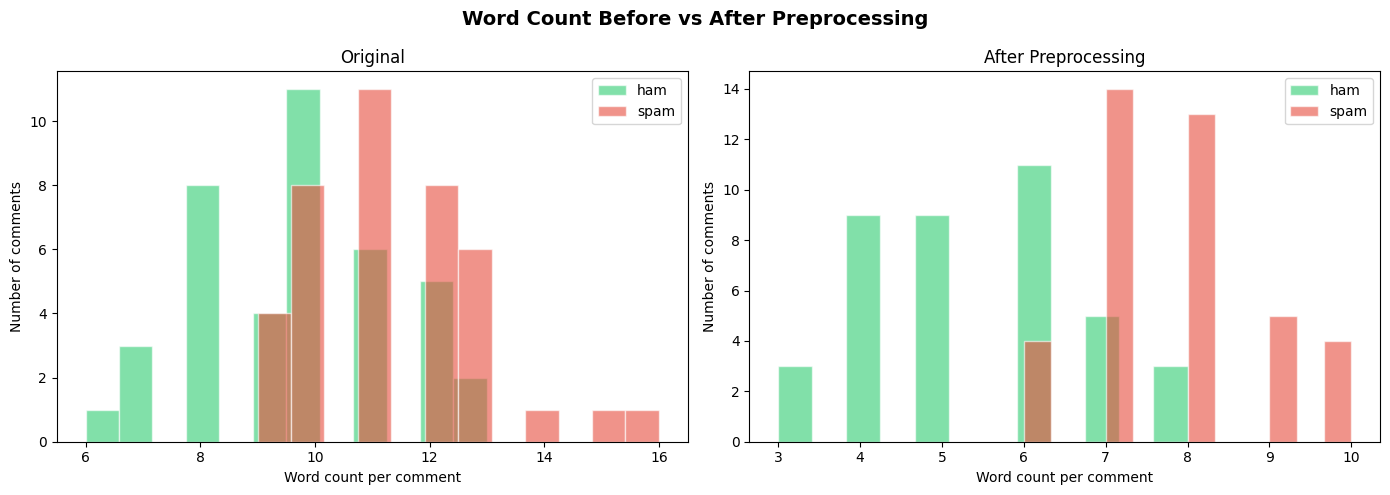


Observation: After removing stopwords and stemming, comments are significantly
shorter but the key signal words are preserved.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add a column for cleaned comment word count (tokens after cleaning)
df['clean_word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df['orig_word_count']  = df['comment'].apply(lambda x: len(x.split()))

# -----------------------------------------------------------------
# Stats comparison
# -----------------------------------------------------------------
print("WORD COUNT COMPARISON (original vs cleaned):\n")
stats = df.groupby('label')[['orig_word_count', 'clean_word_count']].mean().round(1)
stats.columns = ['Avg words (original)', 'Avg words (cleaned)']
stats['Reduction %'] = ((stats['Avg words (original)'] - stats['Avg words (cleaned)'])
                         / stats['Avg words (original)'] * 100).round(1)
print(stats.to_string())

# -----------------------------------------------------------------
# Check for any empty strings after cleaning
# -----------------------------------------------------------------
empty = df[df['clean_comment'].str.strip() == '']
print(f"\nEmpty comments after cleaning: {len(empty)}")

# -----------------------------------------------------------------
# Visualise: original vs cleaned word count distribution
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Word Count Before vs After Preprocessing", fontsize=14, fontweight='bold')

colors = {'ham': '#2ecc71', 'spam': '#e74c3c'}

for ax, col, title in zip(axes,
                           ['orig_word_count', 'clean_word_count'],
                           ['Original', 'After Preprocessing']):
    for label_, color in colors.items():
        subset = df[df['label'] == label_][col]
        ax.hist(subset, bins=12, alpha=0.6, color=color, label=label_, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Word count per comment')
    ax.set_ylabel('Number of comments')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nObservation: After removing stopwords and stemming, comments are significantly")
print("shorter but the key signal words are preserved.")


## Section 7 — Save Processed Dataset

We save a clean version of the dataset with only the two columns the model will need:
- `clean_comment` — the preprocessed text (this is the feature)
- `label` — ham or spam (this is the target)

This file goes to `data/processed/` — processed data is always kept separate
from raw data so we can always re-run preprocessing from scratch if needed.

In [7]:
import os

# Ensure the processed/ directory exists
os.makedirs(os.path.dirname(DATA_OUT), exist_ok=True)

# Select only the columns we need going forward
df_clean = df[['clean_comment', 'label']].copy()
df_clean.columns = ['comment', 'label']   # rename back so downstream code stays simple

# Save to CSV
df_clean.to_csv(DATA_OUT, index=False)

print(f"Saved: {DATA_OUT}")
print(f"Shape: {df_clean.shape}")
print()
print("Preview (first 5 rows):")
print(df_clean.head(5).to_string(index=False))
print()

# Verification read-back
verify = pd.read_csv(DATA_OUT)
print(f"Verification — rows read back: {len(verify)}  | columns: {list(verify.columns)}")


Saved: ..\data\processed\comments_clean.csv
Shape: (80, 2)

Preview (first 5 rows):
                                 comment label
great video realli help understand topic   ham
                make tutori python decor   ham
                      exactli look thank   ham
             ive watch time alreadi help   ham
               could explain part recurs   ham

Verification — rows read back: 80  | columns: ['comment', 'label']


## Section 8 — Stage 3 Summary

In [8]:
print("=" * 60)
print("  PREPROCESSING SUMMARY — Stage 3 Complete")
print("=" * 60)
print(f"  Input file      : data/raw/comments.csv")
print(f"  Output file     : data/processed/comments_clean.csv")
print(f"  Rows processed  : {len(df)}")
print(f"  Empty after clean: {len(df[df['clean_comment'].str.strip() == ''])}")
print()

# Show reduction in vocabulary size
from collections import Counter
import re as _re

def vocab_size(series):
    words = []
    for text in series:
        words.extend(_re.findall(r'\b[a-z]+\b', str(text).lower()))
    return len(set(words))

orig_vocab  = vocab_size(df['comment'])
clean_vocab = vocab_size(df['clean_comment'])

print(f"  Vocabulary (original) : {orig_vocab} unique words")
print(f"  Vocabulary (cleaned)  : {clean_vocab} unique words")
print(f"  Vocabulary reduction  : {orig_vocab - clean_vocab} words removed "
      f"({(orig_vocab - clean_vocab)/orig_vocab*100:.1f}%)")
print()
print("PIPELINE APPLIED:")
print("  1. Lowercase")
print("  2. Remove punctuation and numbers")
print("  3. Tokenize")
print(f"  4. Remove stopwords (NLTK English, {len(STOPWORDS)} words)")
print("  5. Porter Stemming")
print()
print("NEXT STEP: Stage 4 — Feature Extraction")
print("  We will convert cleaned text into numbers using")
print("  Bag-of-Words (CountVectorizer) and TF-IDF.")


  PREPROCESSING SUMMARY — Stage 3 Complete
  Input file      : data/raw/comments.csv
  Output file     : data/processed/comments_clean.csv
  Rows processed  : 80
  Empty after clean: 0

  Vocabulary (original) : 380 unique words
  Vocabulary (cleaned)  : 297 unique words
  Vocabulary reduction  : 83 words removed (21.8%)

PIPELINE APPLIED:
  1. Lowercase
  2. Remove punctuation and numbers
  3. Tokenize
  4. Remove stopwords (NLTK English, 198 words)
  5. Porter Stemming

NEXT STEP: Stage 4 — Feature Extraction
  We will convert cleaned text into numbers using
  Bag-of-Words (CountVectorizer) and TF-IDF.
